# Урок 2. Градиенты и оптимизаторы руками

🎯 **Цели урока**

- вычислять производные численно и понимать, откуда берётся ошибка;
- проверять аналитический градиент (gradient check);
- провести цепное правило для нейрона вручную — это backprop в миниатюре;
- увидеть, как скорость обучения и число обусловленности управляют градиентным спуском;
- написать momentum и Adam с нуля и сравнить их.

📖 **Теория:** раздел «Анализ и оптимизация».

Урок работает без моделей: только NumPy.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)

## 1. Численная производная и её ошибка

Возьмём $f(x) = x^2 \sin x$ с известной производной $f'(x) = 2x \sin x + x^2 \cos x$ и сравним
две разностные схемы при разных шагах $h$.

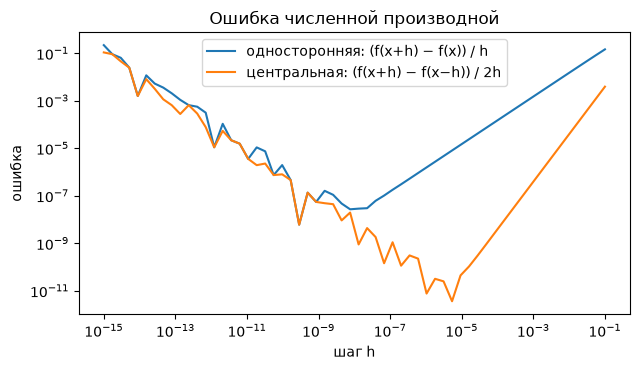

лучший h для центральной схемы ≈ 5e-06, ошибка 3.6e-12


In [2]:
def f(x):
    return x**2 * np.sin(x)


def df(x):
    return 2 * x * np.sin(x) + x**2 * np.cos(x)


x0 = 1.0
hs = np.logspace(-15, -1, 60)
forward = [abs((f(x0 + h) - f(x0)) / h - df(x0)) for h in hs]
central = [abs((f(x0 + h) - f(x0 - h)) / (2 * h) - df(x0)) for h in hs]

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.loglog(hs, forward, label="односторонняя: (f(x+h) − f(x)) / h")
ax.loglog(hs, central, label="центральная: (f(x+h) − f(x−h)) / 2h")
ax.set_xlabel("шаг h")
ax.set_ylabel("ошибка")
ax.legend()
ax.set_title("Ошибка численной производной")
plt.tight_layout()
plt.show()

best = hs[int(np.argmin(central))]
print(f"лучший h для центральной схемы ≈ {best:.0e}, ошибка {min(central):.1e}")

График похож на букву V. Справа ошибка аппроксимации: $O(h)$ у односторонней схемы и $O(h^2)$
у центральной. Слева ошибка округления: при крошечном $h$ мы вычитаем почти равные числа,
и значащие цифры пропадают. Оптимум центральной схемы — около $10^{-5}$.

## 2. Gradient check

Функция потерь линейной регрессии $L(w) = \frac1n \|Xw - y\|^2$ имеет градиент
$\nabla L = \frac2n X^\top (Xw - y)$. Сравним его с численным.

In [3]:
def numerical_grad(fn, w: np.ndarray, h: float = 1e-5) -> np.ndarray:
    """Центральная разность по каждой координате."""
    grad = np.zeros_like(w)
    for i in range(len(w)):
        e = np.zeros_like(w)
        e[i] = h
        grad[i] = (fn(w + e) - fn(w - e)) / (2 * h)
    return grad


X = rng.normal(size=(100, 3))
w_true = np.array([2.0, -1.0, 0.5])
y = X @ w_true + 0.1 * rng.normal(size=100)


def loss(w):
    return np.mean((X @ w - y) ** 2)


def grad(w):
    return 2 / len(y) * X.T @ (X @ w - y)


w = rng.normal(size=3)
g_an, g_num = grad(w), numerical_grad(loss, w)
rel_err = np.linalg.norm(g_an - g_num) / np.linalg.norm(g_an + g_num)
print("аналитический:", g_an)
print("численный:    ", g_num)
print(f"относительная ошибка: {rel_err:.1e}")

аналитический: [-5.5643  2.8359 -3.3169]
численный:     [-5.5643  2.8359 -3.3169]
относительная ошибка: 2.3e-11


Относительная ошибка порядка $10^{-10}$ означает, что формула верна. Если ошибка $10^{-3}$ и больше,
в градиенте баг. Так проверяют собственные слои в PyTorch (`torch.autograd.gradcheck`).

## 3. Цепное правило: нейрон вручную

Один нейрон с сигмоидой и квадратичной ошибкой:
$z = w \cdot x + b$, $a = \sigma(z)$, $L = (a - y)^2$.

Прямой проход считает значения слева направо, обратный — производные справа налево.

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


x = np.array([0.5, -1.0, 2.0])
w = np.array([0.1, 0.4, -0.3])
b, y_true = 0.2, 1.0

# прямой проход
z = w @ x + b
a = sigmoid(z)
L = (a - y_true) ** 2
print(f"z = {z:.4f}, a = {a:.4f}, L = {L:.4f}")

# обратный проход: каждая строка — одно звено цепного правила
dL_da = 2 * (a - y_true)
da_dz = a * (1 - a)          # производная сигмоиды
dL_dz = dL_da * da_dz
dL_dw = dL_dz * x            # dz/dw = x
dL_db = dL_dz * 1.0          # dz/db = 1
print("dL/dw =", dL_dw, " dL/db =", round(dL_db, 4))

# проверка численно
params = np.concatenate([w, [b]])
num = numerical_grad(lambda p: (sigmoid(p[:3] @ x + p[3]) - y_true) ** 2, params)
print("численно:", num)

z = -0.7500, a = 0.3208, L = 0.4613
dL/dw = [-0.148  0.296 -0.592]  dL/db = -0.296
численно: [-0.148  0.296 -0.592 -0.296]


Обратите внимание на `dL_dz`. Он считается один раз и переиспользуется для всех весов.
В большой сети это и делает backprop эффективным: общие «хвосты» производных не пересчитываются.
В M03 мы обобщим этот код до маленькой библиотеки автоматического дифференцирования.

## 4. Градиентный спуск на вытянутой чаше

$f(x) = \frac12 (\lambda_1 x_1^2 + \lambda_2 x_2^2)$ с $\lambda_1 = 1$, $\lambda_2 = 20$:
число обусловленности $\kappa = 20$. Теория говорит: спуск сходится при $\eta < 2/\lambda_{\max} = 0{,}1$.

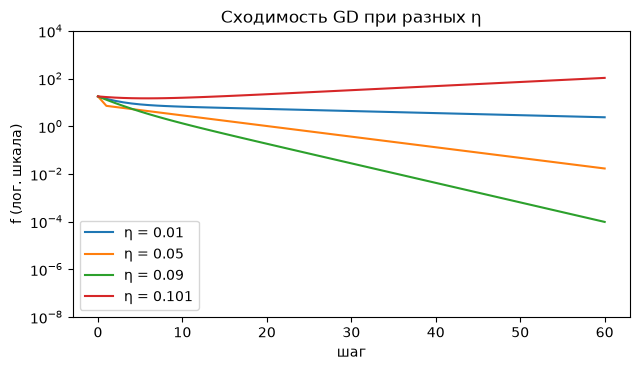

In [5]:
lam = np.array([1.0, 20.0])


def bowl(p):
    return 0.5 * np.sum(lam * p**2)


def bowl_grad(p):
    return lam * p


def gradient_descent(grad_fn, p0, lr, steps):
    path = [np.array(p0, dtype=float)]
    for _ in range(steps):
        path.append(path[-1] - lr * grad_fn(path[-1]))
    return np.array(path)


p0 = [-4.0, 1.0]
fig, ax = plt.subplots(figsize=(6.5, 3.8))
for lr in [0.01, 0.05, 0.09, 0.101]:
    path = gradient_descent(bowl_grad, p0, lr, 60)
    ax.semilogy([bowl(p) for p in path], label=f"η = {lr}")
ax.set_xlabel("шаг")
ax.set_ylabel("f (лог. шкала)")
ax.set_ylim(1e-8, 1e4)
ax.legend()
ax.set_title("Сходимость GD при разных η")
plt.tight_layout()
plt.show()

- $\eta = 0{,}01$ — устойчиво, но медленно: пологая ось $x_1$ за шаг сжимается всего в 0,99 раза.
- $\eta = 0{,}05$ — быстрее. Крутая ось гасится за один шаг ($1 - 0{,}05 \cdot 20 = 0$), а пологая — в 0,95 раза.
- $\eta = 0{,}09$ — ещё быстрее, хотя крутая ось на каждом шаге меняет знак
  ($1 - 0{,}09 \cdot 20 = -0{,}8$). Это тот самый зигзаг: он затухает, и спуск всё равно сходится.
- $\eta = 0{,}101 > 0{,}1$ — крутая ось раскачивается сильнее с каждым шагом, спуск расходится.

Проверим цифрами, как быстро затухает каждая ось: за шаг она умножается на $|1 - \eta\lambda_i|$.

In [6]:
for lr in [0.01, 0.05, 0.09]:
    factors = np.abs(1 - lr * lam)
    print(f"η = {lr}: множители по осям {factors}, скорость определяет худший — {factors.max():.3f}")

η = 0.01: множители по осям [0.99 0.8 ], скорость определяет худший — 0.990
η = 0.05: множители по осям [0.95 0.  ], скорость определяет худший — 0.950
η = 0.09: множители по осям [0.91 0.8 ], скорость определяет худший — 0.910


Лучший $\eta$ уравнивает множители двух осей: $\eta^* = 2/(\lambda_{\min}+\lambda_{\max})$.
Даже тогда худший множитель равен $(\kappa - 1)/(\kappa + 1) \approx 0{,}905$.
Чем сильнее вытянута чаша, тем медленнее GD. Отсюда нужда в momentum и Adam.

## 5. Momentum и Adam с нуля

Функция Розенброка $f(x, y) = (1 - x)^2 + 100 (y - x^2)^2$ — узкий изогнутый овраг
с минимумом в $(1, 1)$. Классический тест для оптимизаторов.

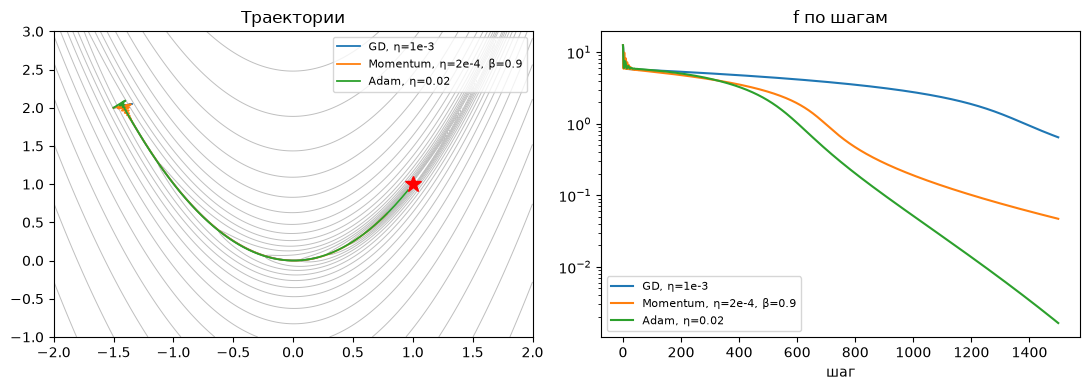

GD, η=1e-3                 через 100 шагов f =    5.5932,  через 1500: 6.47e-01
Momentum, η=2e-4, β=0.9    через 100 шагов f =    5.3388,  через 1500: 4.70e-02
Adam, η=0.02               через 100 шагов f =    5.6152,  через 1500: 1.64e-03


In [7]:
def rosenbrock(p):
    x, y = p
    return (1 - x) ** 2 + 100 * (y - x**2) ** 2


def rosenbrock_grad(p):
    x, y = p
    return np.array([-2 * (1 - x) - 400 * x * (y - x**2), 200 * (y - x**2)])


def sgd(grad_fn, p0, lr, steps):
    p, path = np.array(p0, float), []
    for _ in range(steps):
        path.append(p.copy())
        p = p - lr * grad_fn(p)
    return np.array(path)


def momentum(grad_fn, p0, lr, steps, beta=0.9):
    p, v, path = np.array(p0, float), np.zeros(2), []
    for _ in range(steps):
        path.append(p.copy())
        v = beta * v + grad_fn(p)
        p = p - lr * v
    return np.array(path)


def adam(grad_fn, p0, lr, steps, beta1=0.9, beta2=0.999, eps=1e-8):
    p, m, s, path = np.array(p0, float), np.zeros(2), np.zeros(2), []
    for t in range(1, steps + 1):
        path.append(p.copy())
        g = grad_fn(p)
        m = beta1 * m + (1 - beta1) * g          # первый момент
        s = beta2 * s + (1 - beta2) * g**2       # второй момент
        m_hat = m / (1 - beta1**t)               # поправки на смещение
        s_hat = s / (1 - beta2**t)
        p = p - lr * m_hat / (np.sqrt(s_hat) + eps)
    return np.array(path)


start, steps = [-1.5, 2.0], 1500
runs = {
    "GD, η=1e-3": sgd(rosenbrock_grad, start, 1e-3, steps),
    "Momentum, η=2e-4, β=0.9": momentum(rosenbrock_grad, start, 2e-4, steps),
    "Adam, η=0.02": adam(rosenbrock_grad, start, 0.02, steps),
}

xs, ys = np.meshgrid(np.linspace(-2, 2, 300), np.linspace(-1, 3, 300))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.contour(xs, ys, rosenbrock((xs, ys)), levels=np.logspace(-1, 3.5, 20), colors="0.75", linewidths=0.7)
for name, path in runs.items():
    ax1.plot(path[:, 0], path[:, 1], lw=1.3, label=name)
    ax2.semilogy([rosenbrock(p) for p in path], label=name)
ax1.plot(1, 1, "r*", ms=12)
ax1.set_title("Траектории")
ax1.legend(fontsize=8)
ax2.set_title("f по шагам")
ax2.set_xlabel("шаг")
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

for name, path in runs.items():
    print(f"{name:26} через 100 шагов f = {rosenbrock(path[100]):9.4f},  через {steps}: {rosenbrock(path[-1]):.2e}")

Траектории почти совпадают: за первые шаги все трое скатываются на дно оврага, а дальше ползут
вдоль него к минимуму. Различается скорость (правый график). GD идёт мелкими шагами: больший $\eta$
взорвался бы на крутых стенках. Momentum разгоняется вдоль дна, где градиент всё время смотрит
в одну сторону. Adam нормирует шаг по каждой координате: вдоль пологого дна он шагает так же
смело, как поперёк крутых стенок.

Главное практическое свойство Adam — **масштаб шага не зависит от масштаба градиента**.
Проверим: умножим функцию на 1000.

In [8]:
scaled_grad = lambda p: 1000 * rosenbrock_grad(p)  # noqa: E731
with np.errstate(over="ignore", invalid="ignore"):  # GD переполнится — это и хотим увидеть
    for name, fn, lr in [("GD", sgd, 1e-3), ("Adam", adam, 0.02)]:
        f_plain = rosenbrock(fn(rosenbrock_grad, start, lr, 50)[-1])
        f_scaled = rosenbrock(fn(scaled_grad, start, lr, 50)[-1])
        print(f"{name:5} после 50 шагов: обычный градиент → f = {f_plain:.4g}, градиент × 1000 → f = {f_scaled:.4g}")

GD    после 50 шагов: обычный градиент → f = 5.727, градиент × 1000 → f = nan
Adam  после 50 шагов: обычный градиент → f = 5.838, градиент × 1000 → f = 5.838


GD с тем же $\eta$ разлетается (переполнение → `nan`), а Adam проходит ровно тот же путь:
умножение градиента на константу сокращается в $\hat m / \sqrt{\hat v}$.
Поэтому для нейросетей, где градиенты разных слоёв различаются на порядки, Adam — выбор
по умолчанию.

## 6. Мини-батчи: шум SGD

Градиент по всем данным дорог. SGD оценивает его по мини-батчу. Посмотрим, как размер батча
влияет на шум, на той же линейной регрессии.

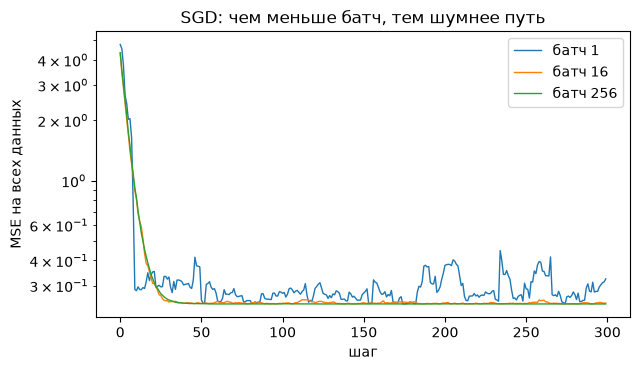

точное решение (МНК): [ 1.9847 -1.0052  0.4866]
SGD, батч 256:        [ 1.9871 -0.9979  0.49  ]


In [9]:
X_big = rng.normal(size=(5000, 3))
y_big = X_big @ w_true + 0.5 * rng.normal(size=5000)


def run_sgd(batch, lr=0.05, steps=300, seed=0):
    r = np.random.default_rng(seed)
    w, losses = np.zeros(3), []
    for _ in range(steps):
        idx = r.integers(0, len(y_big), size=batch)
        xb, yb = X_big[idx], y_big[idx]
        w -= lr * 2 / batch * xb.T @ (xb @ w - yb)
        losses.append(np.mean((X_big @ w - y_big) ** 2))
    return w, losses


fig, ax = plt.subplots(figsize=(6.5, 3.8))
for batch in [1, 16, 256]:
    w_fit, losses = run_sgd(batch)
    ax.plot(losses, label=f"батч {batch}", lw=1)
ax.set_yscale("log")
ax.set_xlabel("шаг")
ax.set_ylabel("MSE на всех данных")
ax.legend()
ax.set_title("SGD: чем меньше батч, тем шумнее путь")
plt.tight_layout()
plt.show()

w_exact = np.linalg.lstsq(X_big, y_big, rcond=None)[0]
print("точное решение (МНК):", w_exact)
print("SGD, батч 256:       ", run_sgd(256)[0])

Шум убывает как $1/\sqrt{B}$. Батч 1 скачет вокруг минимума, батч 256 почти совпадает с полным
градиентом. При обучении LLM батч измеряют в токенах: миллионы токенов на шаг.

## 7. Расписание LR: прогрев и косинус

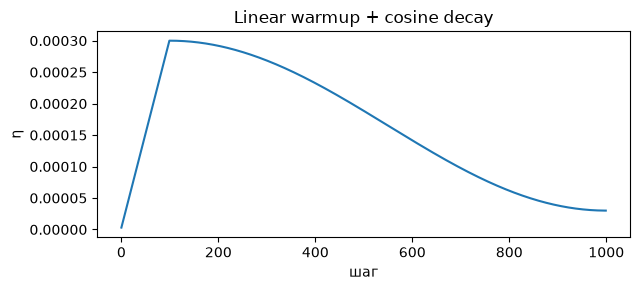

In [10]:
def lr_schedule(step, total=1000, warmup=100, lr_max=3e-4, lr_min=3e-5):
    if step < warmup:
        return lr_max * (step + 1) / warmup
    progress = (step - warmup) / (total - warmup)
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * progress))


fig, ax = plt.subplots(figsize=(6.5, 3))
ax.plot([lr_schedule(s) for s in range(1000)])
ax.set_xlabel("шаг")
ax.set_ylabel("η")
ax.set_title("Linear warmup + cosine decay")
plt.tight_layout()
plt.show()

Такое расписание (с другими числами) используют почти все открытые LLM. В M07 мы увидим его
в конфигурациях обучения.

## ✅ Итоги

- Центральная разность точнее односторонней, но слишком маленький шаг губит точность округлением.
- Gradient check — дешёвая страховка от ошибок в формулах градиента.
- Backprop — цепное правило справа налево с переиспользованием общих множителей.
- GD сходится при $\eta < 2/\lambda_{\max}$, а его скорость упирается в число обусловленности.
- Momentum разгоняется вдоль оврагов, Adam нормирует шаг и нечувствителен к масштабу градиента.

✍️ **Упражнение:** `exercises/ex03_optim.py` — численный градиент, шаги momentum и Adam.